In [30]:
import numpy as np
import matplotlib.pyplot as plt


In [31]:
np.random.seed(42)
input_size=2
hidden_size=2
output_size=1

### randomly initialize weights and biases

In [32]:
w1=np.random.randn(input_size,hidden_size)
b1=np.zeros((1,hidden_size))
w2=np.random.randn(input_size,hidden_size)
b2=np.zeros((1,output_size))



In [33]:
w2

array([[-0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473]])

### sigmoid activation function and its derivative

In [34]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
    return x*(1-x)

### toy dataset(XOR problem)

In [35]:
x=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

### train the neural network using backpropogation

In [36]:
epochs=10000
learning_rate=0.01
losses=[]


### forward propogation

In [37]:
for epoch in range(epochs):
    z1=np.dot(x,w1)+b1
    a1=sigmoid(z1)
    z2=np.dot(a1,w2)+b2
    y_pred=sigmoid(z2)
    loss=np.mean((y_pred-y)**2)
    losses.append(loss)

### backword propogation

In [47]:
d_loss_y_pred=y_pred -y
d_y_pred_z2=sigmoid_derivative(y_pred)
d_z2_w2=a1
d_loss_z2=d_loss_y_pred*d_y_pred_z2
d_loss_w2=np.dot(d_z2_w2.T,d_loss_z2)
d_loss_b2=np.sum(d_loss_z2,axis=0,keepdims=True)
d_z2_a1=w2
d_loss_a1=np.dot(d_loss_z2,d_z2_a1.T)
d_a1_z1=sigmoid(a1)
d_z1_w1=x
d_loss_z1=d_loss_a1*d_a1_z1
d_loss_w1=np.dot(d_z1_w1.T,d_loss_z1)
d_loss_b1=np.sum(d_loss_z1,axis=0,keepdims=True)

### update weights and biases

In [48]:
w2 -=learning_rate*d_loss_w2
b2 -=learning_rate*d_loss_b2
w1 -=learning_rate*d_loss_w1
b1 -=learning_rate*d_loss_b1


ValueError: non-broadcastable output operand with shape (1,1) doesn't match the broadcast shape (1,2)

### visualize the training process

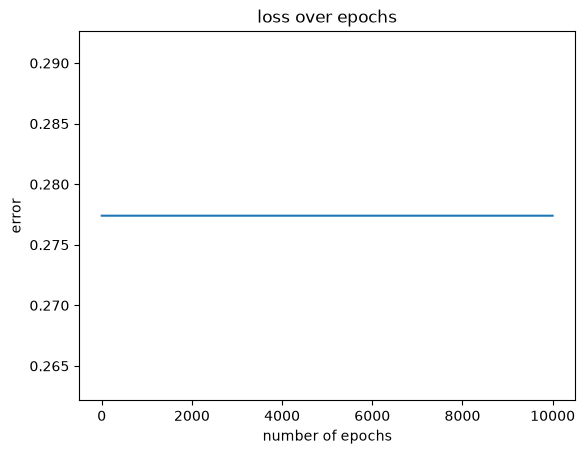

final prediction after training:
[[0.66206937 0.56627003]
 [0.75819144 0.61688404]
 [0.64325866 0.55272142]
 [0.74751103 0.60734607]]


In [40]:
plt.plot(losses)
plt.title("loss over epochs")
plt.xlabel("number of epochs")
plt.ylabel("error")
plt.show()
print("final prediction after training:")
print(y_pred)